In [1]:
import torch # The main deep learning library we'll use (there are others...)
import torchvision # Specialized for vision tasks such as recognizing digits
import matplotlib.pyplot as plt # Helpful for plotting things (like our images!)
from triton.language import tensor

### Real "Deep" Learning!!

Let's jump in with our first model. We will train a logistic classifier (equivalent to a single-layer network with cross entropy loss). The task is to classify images in the popular MNIST data set.

We don't yet have the full background to understand everything that's going on. That's okay. The goal is to give you a first look at how we do deep learning.

We'll begin by loading the data set.

In [2]:
trainingdata = torchvision . datasets. FashionMNIST ('./FashionMNIST/',
    train=True ,download=True , transform = torchvision . transforms . ToTensor ())
testdata = torchvision .datasets. FashionMNIST ('./FashionMNIST/',
    train=False ,download=True , transform = torchvision . transforms . ToTensor ())

Let's take a look at how much training and test data we have.

In [3]:
print(f'There are {len(trainingdata)} training images.')
print(f'There are {len(testdata)} test images.')

There are 60000 training images.
There are 10000 test images.


That's a lot! But perfect for our favorite big data, deep learning setting. Let's look inside to see one of these examples.

In [4]:
image, label = trainingdata[0]
print(image.shape) # A 1x28x28 image. This means one color and on a grid of 28x28 pixels.
print(label) # A single number corresponding to the label of this image.

torch.Size([1, 28, 28])
9


We can't directly plot the image because of formatting constraints that the first dimension can't have a size of 1. Instead, we'll use the `squeeze` function to turn it into a 28x28 image that we can plot.

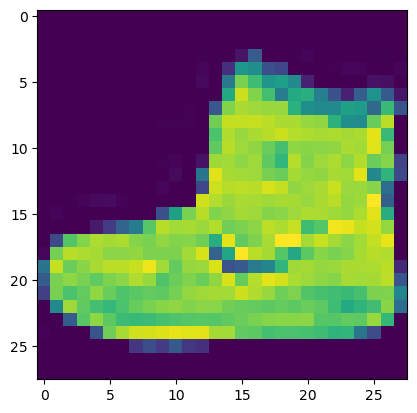

In [5]:
plt.imshow(image.squeeze()) # Plot the 28x28 image
plt.show()

In [6]:
# The DataLoader is a nifty class for wrapping the data so we can load batches easily
trainDataLoader = torch.utils.data.DataLoader(trainingdata,batch_size=64,shuffle=True)
testDataLoader = torch.utils.data.DataLoader(testdata,batch_size=64,shuffle=False)

images, labels = next(iter(trainDataLoader)) # Let's take a look at an example batch
print(images.shape) # There are 64 images
print(labels.shape) # And the corresponding 64 labels

torch.Size([64, 1, 28, 28])
torch.Size([64])


We loaded a batch with 64 images and labels. Let's say we wanted to do a batch of 128, how would you accomplish that by modifying the code above?

Now that we have our data, let's define our model, loss function, and optimizer using our three step recipe for machine learning.

In [7]:
# We write this in the standard python class format
class Model(torch.nn.Module):
  def __init__(self): # This runs whenever we initialize a new model
    super(Model, self).__init__()
    self.l1 = torch.nn.Linear(28*28, 128)
    self.relu1 = torch.nn.ReLU()
    self.l2 = torch.nn.Linear(128, 64)
    self.relu2 = torch.nn.ReLU()
    self.l3 = torch.nn.Linear(64, 10)
    # We define a layer with input size 28*28 and output 10

  def forward(self, x): # This runs when we call the model on x
    x = x.view(-1, 28*28) # Change from 28x28 view to 784 vector
    x = self.l1(x)
    x = self.relu1(x)
    x = self.l2(x)
    x = self.relu2(x)
    x = self.l3(x)
    return x

# Step 1: Model
model = Model() # Use the class we just defined
# Step 2: Loss
loss = torch.nn.CrossEntropyLoss()
# Step 3: Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01) # Use stochastic gradient descent on the weights in the model



We also want to run everything quickly on a GPU. A GPU enables us to (basically) to matrix multiplication fast.

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'We\'re using the {device}.')
# Put the model on the device
model = model.to(device)

We're using the cuda.


Now let's do some training!! We'll treat the training process as a bit of a black box for now.

As we go, we'll keep track of the training and test loss so we can visualize how they change later.

In [9]:
train_losses = []
test_losses = []
epoch = 32

for epoch in range(epoch): # We'll train for 5 "epochs"
  train_loss = 0
  test_loss = 0

  # Evaluation process
  for i, data in enumerate(testDataLoader):
    images, labels = data # Unpack the data into the images and labels
    images, labels = images.to(device), labels.to(device) # Put on device
    predicted_output = model(images) # Apply our network to the images
    fit = loss(predicted_output, labels) # Measure how well the predicted output matches the labels
    test_loss += fit.item() # Add the fit to the loss for tracking purposes

  # Training process
  for i, data in enumerate(trainDataLoader):
    images, labels = data # Unpack the data into the images and labels
    images, labels = images.to(device), labels.to(device) # Put on device
    optimizer.zero_grad() # Zero out the gradient values
    predicted_output = model(images) # Apply our network to the images
    fit = loss(predicted_output, labels) # Measure how well the predicted output matches the labels
    fit.backward() # Compute the gradient of the fit with respect to the model parameters
    optimizer.step() # Update the weights in the model using gradient descent
    train_loss += fit.item() # Add the fit to the loss for tracking purposes

  # Add the current losses to our tracking lists
  train_losses += [train_loss/len(trainDataLoader)]
  test_losses += [test_loss/len(testDataLoader)]

  # Print the current loss
  print(f'Epoch {epoch}, Train loss {train_loss}, Test loss {test_loss}')

Epoch 0, Train loss 1334.1038606762886, Test loss 362.5509991645813
Epoch 1, Train loss 686.2716274261475, Test loss 135.2413296699524
Epoch 2, Train loss 569.4923595190048, Test loss 108.4470057785511
Epoch 3, Train loss 512.6038354933262, Test loss 93.09315225481987
Epoch 4, Train loss 480.2454092055559, Test loss 86.32337963581085
Epoch 5, Train loss 458.57352824509144, Test loss 82.34889057278633
Epoch 6, Train loss 442.69226709008217, Test loss 79.61303658783436
Epoch 7, Train loss 429.45846162736416, Test loss 76.51379816234112
Epoch 8, Train loss 418.2607737481594, Test loss 74.8004098534584
Epoch 9, Train loss 409.26494754850864, Test loss 79.5320053100586
Epoch 10, Train loss 400.6162938475609, Test loss 75.58489598333836
Epoch 11, Train loss 393.4699669033289, Test loss 72.3693695962429
Epoch 12, Train loss 386.4293909519911, Test loss 70.85046988725662
Epoch 13, Train loss 379.9675595611334, Test loss 71.11624182760715
Epoch 14, Train loss 374.3486255854368, Test loss 73.267

Let's plot our loss by training epoch to see how we did over time.

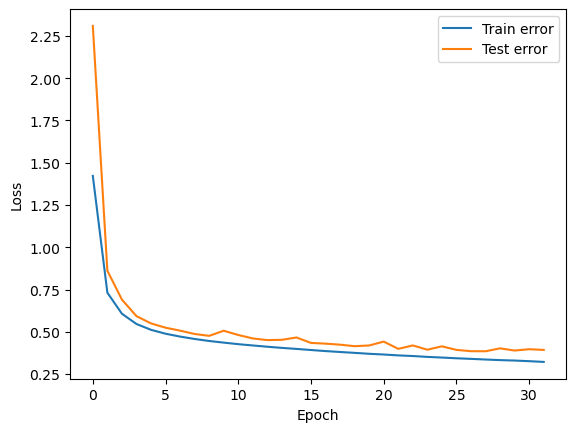

In [10]:
plt.plot(range(epoch+1),train_losses, label='Train error')
plt.plot(range(epoch+1),test_losses, label='Test error')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

The test loss is always larger than the training loss. Why is that?

Let's look at an example to see how well the model does. We'll use the variables from the last pass of the training process.

In [11]:
predicted_classes = torch.max(predicted_output, 1)[1]
print('Predicted:', predicted_classes)
print('Labels:', labels)


Predicted: tensor([7, 2, 9, 0, 6, 3, 3, 6, 7, 6, 7, 6, 5, 7, 2, 4, 6, 6, 3, 6, 5, 5, 3, 3,
        6, 4, 1, 5, 1, 2, 7, 7], device='cuda:0')
Labels: tensor([7, 2, 9, 0, 6, 3, 3, 6, 7, 6, 7, 6, 5, 7, 2, 4, 0, 6, 3, 6, 5, 5, 3, 6,
        6, 4, 1, 5, 1, 2, 7, 7], device='cuda:0')


In [12]:
def plotter(probabilities: list[float]):
    class_labels = range(len(probabilities))
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_labels, probabilities, color='skyblue')
    plt.title('Softmax Probability Distribution', fontsize=16)
    plt.xlabel('Class Index', fontsize=12)
    plt.ylabel('Probability', fontsize=12)
    plt.xticks(class_labels)
    plt.ylim(0, 1)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')
    plt.show()

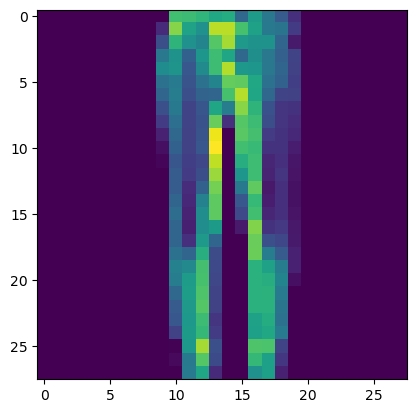

Index: 65 | True Label: 1 | Predicted Label: 1 | Possibilities: [9.968826634576544e-05, 0.9975390434265137, 6.722583202645183e-05, 0.0021606916561722755, 0.00012265842815395445, 4.420116184178369e-08, 3.135022780043073e-06, 5.722135028918274e-06, 1.0836632782229572e-06, 7.08902746282547e-07], visualize: 


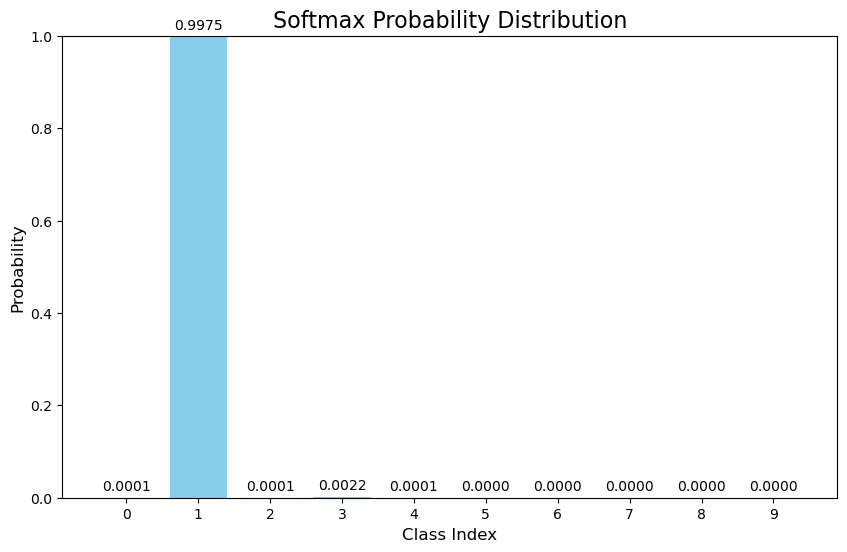

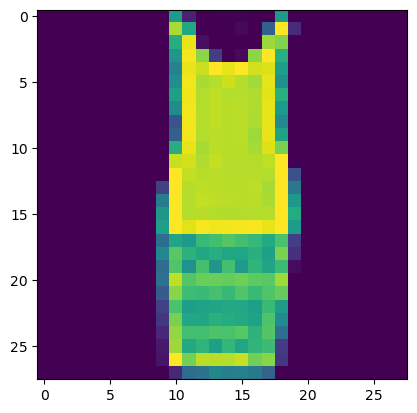

Index: 5422 | True Label: 3 | Predicted Label: 3 | Possibilities: [0.000543696281965822, 0.05208674073219299, 0.00010737486445577815, 0.9459827542304993, 0.00042966846376657486, 2.7317862532072468e-06, 0.00016221705300267786, 0.00042062444845214486, 0.0002546147152315825, 9.575137482897844e-06], visualize: 


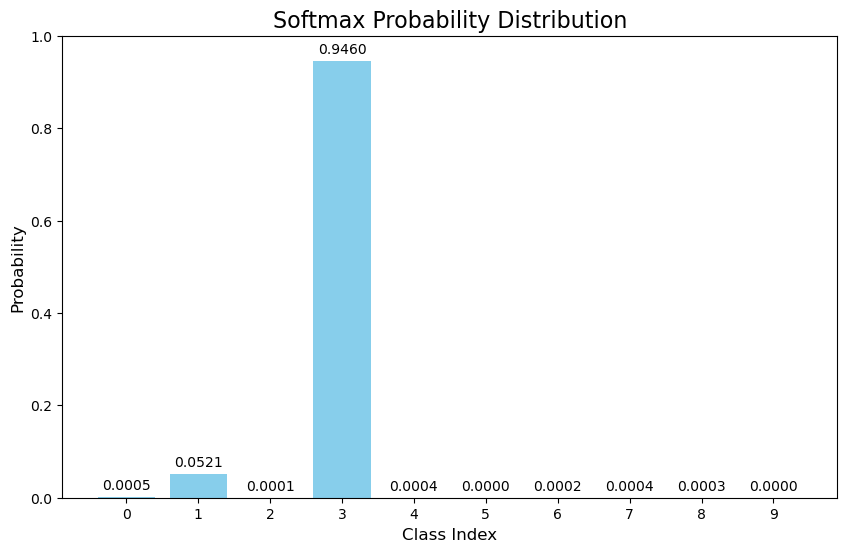

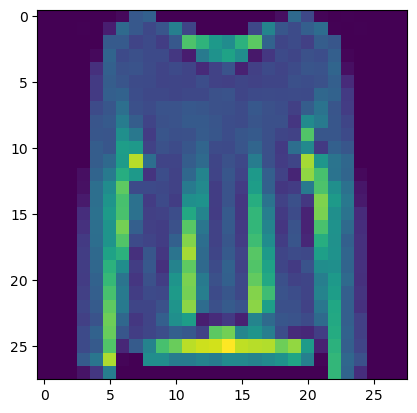

Index: 3456 | True Label: 2 | Predicted Label: 2 | Possibilities: [0.008627957664430141, 0.00033241810160689056, 0.9050952196121216, 0.00217223446816206, 0.00869831908494234, 0.00020685652270913124, 0.06777142733335495, 6.562547838484534e-08, 0.007085295859724283, 1.0250511877529789e-05], visualize: 


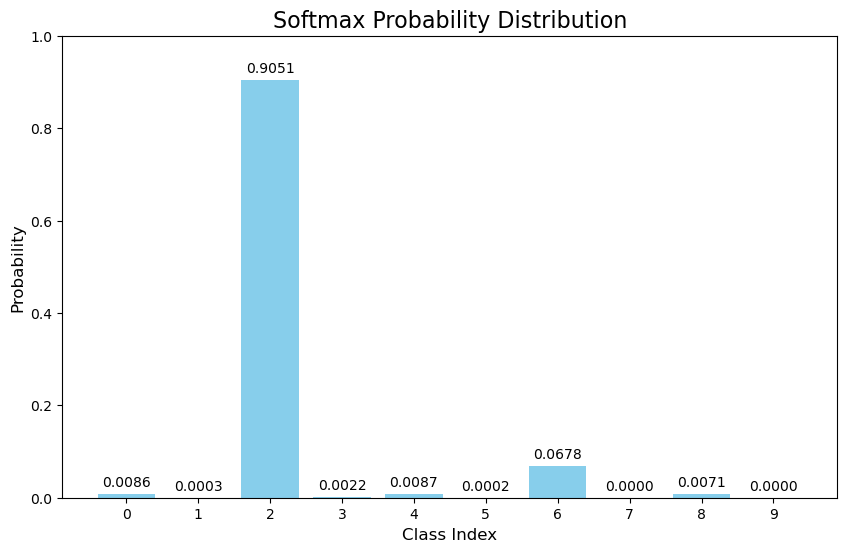

In [13]:
num_samples = len(testdata)
random_indices = torch.randperm(num_samples)[:3].tolist()
for i in random_indices:
    image, label = testdata[i]
    plt.imshow(image.squeeze())
    plt.show()
    image = image.unsqueeze(0)
    image = image.to(device)
    label = torch.tensor(label).to(device)
    with torch.no_grad():
        predicted_output: torch.Tensor = model(image)
    predicted_class = torch.argmax(predicted_output, dim=1)

    print(f"Index: {i} | True Label: {label.item()} | Predicted Label: {predicted_class.item()} "
          f"| Possibilities: {predicted_output[0].softmax(0).tolist()}, visualize: ")
    plotter(predicted_output[0].softmax(0).tolist())
    # print("Raw model output (logits):", predicted_output)

# Observations
- For correct predictions, the possibility of the correct class will be much higher than other classes. In come extreme cases, other classes will be near 0.

- For incorrect predictions, the correct answer and the predicted answer have similar probabilities. There is no incorrect cases that the incorrect class has much higher probability than other classes.

These two observations show that the model we trained is successful.